# 04 — **Predictive Modeling**

This notebook trains and compares models for two early-warning points:

- **Enrollment-stage model:** uses information available at or near enrollment.
- **Semester 1 model:** adds first-semester academic information and engineered features.

The modeling process will include:

- train/test splitting
- preprocessing within pipelines
- baseline comparison
- candidate model training
- feature selection
- PCA comparison
- model evaluation

The main evaluation metric is **Recall for the Dropout class**, supported by precision, F1-score, ROC-AUC, PR-AUC, and confusion matrices.

The same train/test split will be used for both prediction windows so their performance can be compared fairly.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

RANDOM_STATE = 42

In [2]:
from pathlib import Path
import pandas as pd

repo_dir = Path("/content/student-dropout-capstone")

if not repo_dir.exists():
    !git clone https://github.com/rayvaril/student-dropout-capstone.git

enrollment_path = repo_dir / "data/processed/enrollment_model_base.csv"
semester1_path = repo_dir / "data/processed/semester1_model_base.csv"

enrollment_df = pd.read_csv(enrollment_path)
semester1_df = pd.read_csv(semester1_path)

print("Enrollment dataset:", enrollment_df.shape)
print("Semester 1 dataset:", semester1_df.shape)

Cloning into 'student-dropout-capstone'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 91 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 726.30 KiB | 2.74 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Enrollment dataset: (4424, 23)
Semester 1 dataset: (4424, 34)


In [3]:
print("Enrollment columns:")
print(enrollment_df.columns.tolist())

print("\nSemester 1 columns:")
print(semester1_df.columns.tolist())

Enrollment columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Unemployment rate', 'Inflation rate', 'GDP', 'Dropout_binary']

Semester 1 columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Unemployment rate', 'Inflation rate', 'GDP', 'Curricular units 1st sem (credited)', 'C

In [5]:
# Confirm both datasets contain the same students in the same order
assert len(enrollment_df) == len(semester1_df)
assert enrollment_df["Dropout_binary"].equals(
    semester1_df["Dropout_binary"]
)

target = enrollment_df["Dropout_binary"]

# Split row indices so both prediction windows use the same students
all_indices = np.arange(len(enrollment_df))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target
)

# Enrollment-stage data
X_enroll_train = enrollment_df.drop(columns="Dropout_binary").iloc[train_idx]
X_enroll_test = enrollment_df.drop(columns="Dropout_binary").iloc[test_idx]

# Semester 1 data
X_sem1_train = semester1_df.drop(columns="Dropout_binary").iloc[train_idx]
X_sem1_test = semester1_df.drop(columns="Dropout_binary").iloc[test_idx]

# Same target for both models
y_train = target.iloc[train_idx]
y_test = target.iloc[test_idx]

print("Training students:", len(train_idx))
print("Test students:", len(test_idx))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training students: 3539
Test students: 885

Training target distribution:
Dropout_binary
0    0.6787
1    0.3213
Name: proportion, dtype: float64

Test target distribution:
Dropout_binary
0    0.6791
1    0.3209
Name: proportion, dtype: float64


### **Split Check**

An 80/20 stratified train/test split was used.

The dropout rate remained approximately 32% in both sets, and the same student indices are used for the Enrollment and Semester 1 models. This allows a fair comparison between the two prediction windows.

The test set will remain untouched during model training, feature selection, and hyperparameter tuning.

In [7]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Gender",
    "Scholarship holder",
    "International"
]

ordinal_features = [
    "Application order"
]

enrollment_numeric_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

semester1_additional_numeric = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "sem1_approval_rate",
    "sem1_evaluations_per_enrolled",
    "sem1_completion_gap",
    "sem1_no_approved_units",
    "sem1_no_enrolled_units"
]

semester1_numeric_features = (
    enrollment_numeric_features
    + semester1_additional_numeric
)

print("Categorical:", len(categorical_features))
print("Ordinal:", len(ordinal_features))
print("Enrollment numeric:", len(enrollment_numeric_features))
print("Semester 1 numeric:", len(semester1_numeric_features))

print(
    "\nEnrollment total:",
    len(categorical_features)
    + len(ordinal_features)
    + len(enrollment_numeric_features)
)

print(
    "Semester 1 total:",
    len(categorical_features)
    + len(ordinal_features)
    + len(semester1_numeric_features)
)

Categorical: 15
Ordinal: 1
Enrollment numeric: 6
Semester 1 numeric: 17

Enrollment total: 22
Semester 1 total: 33


In [8]:
def build_preprocessor(numeric_features, scale_numeric=True):
    numeric_and_ordinal = ordinal_features + numeric_features

    categorical_transformer = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=30,
        sparse_output=False
    )

    numeric_transformer = (
        StandardScaler()
        if scale_numeric
        else "passthrough"
    )

    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                categorical_transformer,
                categorical_features
            ),
            (
                "numeric",
                numeric_transformer,
                numeric_and_ordinal
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )


# Preprocessing for linear models
enroll_linear_preprocessor = build_preprocessor(
    enrollment_numeric_features,
    scale_numeric=True
)

sem1_linear_preprocessor = build_preprocessor(
    semester1_numeric_features,
    scale_numeric=True
)

# Preprocessing for tree-based models
enroll_tree_preprocessor = build_preprocessor(
    enrollment_numeric_features,
    scale_numeric=False
)

sem1_tree_preprocessor = build_preprocessor(
    semester1_numeric_features,
    scale_numeric=False
)

print("Preprocessors created successfully.")

Preprocessors created successfully.


In [9]:
baseline_results = []

for window_name, X_train, X_test in [
    ("Enrollment", X_enroll_train, X_enroll_test),
    ("Semester 1", X_sem1_train, X_sem1_test)
]:
    baseline = DummyClassifier(
        strategy="most_frequent"
    )

    baseline.fit(X_train, y_train)

    y_pred = baseline.predict(X_test)

    baseline_results.append({
        "Prediction Window": window_name,
        "Model": "Dummy - Most Frequent",
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,Prediction Window,Model,Recall,Precision,F1
0,Enrollment,Dummy - Most Frequent,0.0,0.0,0.0
1,Semester 1,Dummy - Most Frequent,0.0,0.0,0.0


### **Baseline Assessment**

The majority-class baseline fails to identify any students who eventually drop out, resulting in zero recall, precision, and F1-score for the Dropout class.

This confirms that majority-class prediction is not useful for the early-warning objective and provides a minimum reference point for the predictive models.

In [10]:
logistic_results = []
logistic_models = {}

for (
    window_name,
    X_train,
    X_test,
    preprocessor
) in [
    (
        "Enrollment",
        X_enroll_train,
        X_enroll_test,
        enroll_linear_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        X_sem1_test,
        sem1_linear_preprocessor
    )
]:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    logistic_results.append({
        "Prediction Window": window_name,
        "Model": "Logistic Regression",
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

    logistic_models[window_name] = model

logistic_results_df = pd.DataFrame(logistic_results)

logistic_results_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC
0,Enrollment,Logistic Regression,0.482,0.685,0.566,0.787,0.651
1,Semester 1,Logistic Regression,0.683,0.805,0.739,0.892,0.836


### **Logistic Regression Assessment**

Logistic Regression performs better than the majority-class baseline for both prediction windows.

The Semester 1 model shows stronger performance than the Enrollment model across all reported metrics. Dropout recall increases from 0.482 to 0.683, while ROC-AUC increases from 0.787 to 0.892.

This suggests that first-semester academic information adds useful predictive signal. However, these results do not determine the final model because other algorithms and tuned configurations still need to be compared.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import GradientBoostingClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "Recall": "recall",
    "Precision": "precision",
    "F1": "f1",
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision"
}

print("Cross-validation setup:")
print("Folds:", cv.get_n_splits())
print("Metrics:", list(scoring.keys()))

Cross-validation setup:
Folds: 5
Metrics: ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']


In [12]:
candidate_results = []

model_specs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "preprocessor_type": "linear"
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "preprocessor_type": "tree"
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        "preprocessor_type": "tree"
    }
}

windows = {
    "Enrollment": {
        "X": X_enroll_train,
        "linear_preprocessor": enroll_linear_preprocessor,
        "tree_preprocessor": enroll_tree_preprocessor
    },

    "Semester 1": {
        "X": X_sem1_train,
        "linear_preprocessor": sem1_linear_preprocessor,
        "tree_preprocessor": sem1_tree_preprocessor
    }
}

for window_name, window_info in windows.items():

    for model_name, spec in model_specs.items():

        if spec["preprocessor_type"] == "linear":
            preprocessor = window_info["linear_preprocessor"]
        else:
            preprocessor = window_info["tree_preprocessor"]

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", spec["model"])
            ]
        )

        cv_scores = cross_validate(
            pipeline,
            window_info["X"],
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        candidate_results.append({
            "Prediction Window": window_name,
            "Model": model_name,
            "Recall": cv_scores["test_Recall"].mean(),
            "Precision": cv_scores["test_Precision"].mean(),
            "F1": cv_scores["test_F1"].mean(),
            "ROC-AUC": cv_scores["test_ROC-AUC"].mean(),
            "PR-AUC": cv_scores["test_PR-AUC"].mean(),
            "Recall SD": cv_scores["test_Recall"].std()
        })

cv_results_df = pd.DataFrame(candidate_results)

cv_results_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Logistic Regression,0.422,0.639,0.508,0.768,0.616,0.017
1,Enrollment,Random Forest,0.398,0.652,0.493,0.761,0.600,0.010
2,Enrollment,Gradient Boosting,0.406,0.641,0.497,0.768,0.613,0.020
3,Semester 1,Logistic Regression,0.645,0.779,0.705,0.883,0.825,0.028
4,Semester 1,Random Forest,0.648,0.797,0.714,0.877,0.816,0.034
5,Semester 1,Gradient Boosting,0.656,0.796,0.718,0.883,0.822,0.032


### **Cross-Validation Assessment**

The Semester 1 models consistently outperform the Enrollment-stage models, showing that first-semester academic information adds substantial predictive value.

For the Enrollment window, Logistic Regression has the highest recall at 0.422, although performance is similar across the three models.

For Semester 1, Gradient Boosting has the highest recall at 0.656 and the highest F1-score at 0.718. Random Forest has slightly higher precision, while Logistic Regression and Gradient Boosting have the highest ROC-AUC at 0.883.

Recall variability across folds is relatively low, suggesting that the results are reasonably stable.

These are untuned cross-validation results. Hyperparameter tuning will be performed before final model selection.

In [13]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

tuned_logistic_results = {}
tuned_logistic_models = {}

for window_name, X_train, preprocessor in [
    (
        "Enrollment",
        X_enroll_train,
        enroll_linear_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        sem1_linear_preprocessor
    )
]:

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=logistic_param_grid,
        scoring=scoring,
        refit="Recall",
        cv=cv,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    tuned_logistic_models[window_name] = search.best_estimator_

    tuned_logistic_results[window_name] = {
        "Best Parameters": search.best_params_,
        "Best CV Recall": search.best_score_
    }

for window_name, result in tuned_logistic_results.items():
    print(f"\n{window_name}")
    print("Best parameters:", result["Best Parameters"])
    print("Best CV recall:", round(result["Best CV Recall"], 3))


Enrollment
Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best CV recall: 0.706

Semester 1
Best parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced'}
Best CV recall: 0.771


### **Logistic Regression Tuning**

Class-weight balancing substantially improved dropout recall for both prediction windows.

The best Enrollment configuration used
`C = 0.1` with balanced class weights, while the Semester 1 model used
`C = 1` with balanced class weights.

Because the models were selected using recall, the corresponding precision, F1-score, ROC-AUC, and PR-AUC must also be reviewed before deciding whether the improvement is operationally useful.

In [14]:
tuned_logistic_cv_results = []

for window_name, search in [
    ("Enrollment", None),
    ("Semester 1", None)
]:
    model = tuned_logistic_models[window_name]

    X_train = (
        X_enroll_train
        if window_name == "Enrollment"
        else X_sem1_train
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_logistic_cv_results.append({
        "Prediction Window": window_name,
        "Model": "Tuned Logistic Regression",
        "Recall": scores["test_Recall"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "F1": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "Recall SD": scores["test_Recall"].std()
    })

tuned_logistic_cv_df = pd.DataFrame(
    tuned_logistic_cv_results
)

tuned_logistic_cv_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Tuned Logistic Regression,0.706,0.524,0.601,0.769,0.614,0.028
1,Semester 1,Tuned Logistic Regression,0.771,0.692,0.729,0.883,0.823,0.020


### **Tuned Logistic Regression Assessment**

Using balanced class weights substantially increased dropout recall, with a corresponding decrease in precision.

For the Enrollment model, recall increased from 0.422 to 0.706, while precision decreased from 0.639 to 0.524. Despite this trade-off, F1 improved from 0.508 to 0.601.

For Semester 1, recall increased from 0.645 to 0.771, while precision decreased from 0.779 to 0.692. F1 also improved slightly from 0.705 to 0.729.

ROC-AUC and PR-AUC changed very little, suggesting that class balancing mainly affected the classification trade-off rather than the model's overall ranking ability.

The tuned Logistic Regression remains a candidate model, but it will be compared with tuned tree-based models before final selection.

In [15]:
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 3],
    "classifier__class_weight": [None, "balanced"]
}

tuned_rf_results = {}
tuned_rf_models = {}

for window_name, X_train, preprocessor in [
    (
        "Enrollment",
        X_enroll_train,
        enroll_tree_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        sem1_tree_preprocessor
    )
]:

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=rf_param_grid,
        scoring=scoring,
        refit="Recall",
        cv=cv,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    tuned_rf_models[window_name] = search.best_estimator_

    tuned_rf_results[window_name] = {
        "Best Parameters": search.best_params_,
        "Best CV Recall": search.best_score_
    }

for window_name, result in tuned_rf_results.items():
    print(f"\n{window_name}")
    print("Best parameters:", result["Best Parameters"])
    print("Best CV recall:", round(result["Best CV Recall"], 3))


Enrollment
Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 400}
Best CV recall: 0.632

Semester 1
Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 400}
Best CV recall: 0.727


### R**andom Forest Tuning**

The best Random Forest configuration used balanced class weights, a maximum depth of 10, a minimum leaf size of 3, and 400 trees for both prediction windows.

Tuning improved dropout recall compared with the untuned Random Forest.

However, the tuned Random Forest still has lower recall than the tuned Logistic Regression for both Enrollment and Semester 1.

The full precision-recall trade-off will be reviewed before comparing it with the other tuned models.

In [16]:
tuned_rf_cv_results = []

for window_name in ["Enrollment", "Semester 1"]:

    model = tuned_rf_models[window_name]

    X_train = (
        X_enroll_train
        if window_name == "Enrollment"
        else X_sem1_train
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_rf_cv_results.append({
        "Prediction Window": window_name,
        "Model": "Tuned Random Forest",
        "Recall": scores["test_Recall"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "F1": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "Recall SD": scores["test_Recall"].std()
    })

tuned_rf_cv_df = pd.DataFrame(tuned_rf_cv_results)

tuned_rf_cv_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Tuned Random Forest,0.632,0.548,0.587,0.763,0.602,0.021
1,Semester 1,Tuned Random Forest,0.727,0.728,0.727,0.879,0.815,0.032


### **Tuned Random Forest Assessment**

The tuned Random Forest provides a more balanced precision-recall trade-off than the tuned Logistic Regression, particularly for the Semester 1 model.

However, its dropout recall remains lower than the tuned Logistic Regression for both prediction windows.

For Semester 1, Random Forest achieves nearly equal recall and precision at about 0.73, which may be useful when both missed dropouts and unnecessary interventions matter.

Final model selection will consider these trade-offs alongside the tuned Gradient Boosting results.

In [17]:
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3],
    "classifier__min_samples_leaf": [1, 3]
}

tuned_gb_results = {}
tuned_gb_models = {}

for window_name, X_train, preprocessor in [
    (
        "Enrollment",
        X_enroll_train,
        enroll_tree_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        sem1_tree_preprocessor
    )
]:

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                GradientBoostingClassifier(
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=gb_param_grid,
        scoring=scoring,
        refit="Recall",
        cv=cv,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    tuned_gb_models[window_name] = search.best_estimator_

    tuned_gb_results[window_name] = {
        "Best Parameters": search.best_params_,
        "Best CV Recall": search.best_score_
    }

for window_name, result in tuned_gb_results.items():
    print(f"\n{window_name}")
    print("Best parameters:", result["Best Parameters"])
    print("Best CV recall:", round(result["Best CV Recall"], 3))


Enrollment
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best CV recall: 0.431

Semester 1
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 200}
Best CV recall: 0.669


### **Gradient Boosting Tuning**

Gradient Boosting produced only a modest improvement in dropout recall after tuning.

The best Enrollment model achieved a cross-validated recall of 0.431, while the best Semester 1 model achieved 0.669.

These values remain below the tuned Logistic Regression and Random Forest results on the primary recall metric.

The full set of evaluation metrics will be reviewed before comparing the tuned models.

In [18]:
tuned_gb_cv_results = []

for window_name in ["Enrollment", "Semester 1"]:

    model = tuned_gb_models[window_name]

    X_train = (
        X_enroll_train
        if window_name == "Enrollment"
        else X_sem1_train
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_gb_cv_results.append({
        "Prediction Window": window_name,
        "Model": "Tuned Gradient Boosting",
        "Recall": scores["test_Recall"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "F1": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "Recall SD": scores["test_Recall"].std()
    })

tuned_gb_cv_df = pd.DataFrame(tuned_gb_cv_results)

tuned_gb_cv_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Tuned Gradient Boosting,0.431,0.629,0.512,0.767,0.611,0.021
1,Semester 1,Tuned Gradient Boosting,0.669,0.799,0.728,0.881,0.823,0.030


In [19]:
tuned_model_comparison = pd.concat(
    [
        tuned_logistic_cv_df,
        tuned_rf_cv_df,
        tuned_gb_cv_df
    ],
    ignore_index=True
)

tuned_model_comparison = tuned_model_comparison.sort_values(
    by=["Prediction Window", "Recall"],
    ascending=[True, False]
)

tuned_model_comparison.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Tuned Logistic Regression,0.706,0.524,0.601,0.769,0.614,0.028
2,Enrollment,Tuned Random Forest,0.632,0.548,0.587,0.763,0.602,0.021
4,Enrollment,Tuned Gradient Boosting,0.431,0.629,0.512,0.767,0.611,0.021
1,Semester 1,Tuned Logistic Regression,0.771,0.692,0.729,0.883,0.823,0.020
3,Semester 1,Tuned Random Forest,0.727,0.728,0.727,0.879,0.815,0.032
5,Semester 1,Tuned Gradient Boosting,0.669,0.799,0.728,0.881,0.823,0.030


### **Tuned Model Comparison**

Tuned Logistic Regression achieves the highest dropout recall for both prediction windows.

For the Enrollment model, Logistic Regression reaches a recall of 0.706, compared with 0.632 for Random Forest and 0.431 for Gradient Boosting.

For Semester 1, Logistic Regression again has the highest recall at 0.771. Random Forest provides a more balanced precision-recall trade-off, while Gradient Boosting has the highest precision.

ROC-AUC and PR-AUC are similar across the Semester 1 models, suggesting that the main difference is how each model trades precision for recall rather than a large difference in overall ranking ability.

No final model is selected yet. Feature selection and dimensionality-reduction experiments will be completed before final evaluation on the held-out test set.

In [20]:
from sklearn.feature_selection import SelectFromModel

feature_selection_results = []
feature_selection_models = {}

for window_name, X_train, preprocessor in [
    (
        "Enrollment",
        X_enroll_train,
        enroll_linear_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        sem1_linear_preprocessor
    )
]:

    selector = SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.1,
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        threshold=1e-6
    )

    final_classifier = LogisticRegression(
        C=(
            0.1
            if window_name == "Enrollment"
            else 1
        ),
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("feature_selection", selector),
            ("classifier", final_classifier)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    feature_selection_results.append({
        "Prediction Window": window_name,
        "Model": "Logistic + L1 Feature Selection",
        "Recall": scores["test_Recall"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "F1": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "Recall SD": scores["test_Recall"].std()
    })

    feature_selection_models[window_name] = pipeline

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Logistic + L1 Feature Selection,0.700,0.513,0.592,0.764,0.604,0.031
1,Semester 1,Logistic + L1 Feature Selection,0.765,0.689,0.724,0.878,0.814,0.024


### **Feature Selection Assessment**

L1-based feature selection preserves most of the performance of the full tuned Logistic Regression models.

For Enrollment, recall decreases only slightly from 0.706 to 0.700. For Semester 1, recall decreases from 0.771 to 0.765.

The small performance change suggests that some transformed features may be removed without substantially reducing predictive performance.

The selected feature count and retained features will be inspected before deciding whether feature selection should be used in the final model.

In [21]:
selected_feature_summary = {}

for window_name, pipeline in feature_selection_models.items():

    X_train = (
        X_enroll_train
        if window_name == "Enrollment"
        else X_sem1_train
    )

    # Fit on training data only
    fitted_pipeline = pipeline.fit(X_train, y_train)

    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    selector = fitted_pipeline.named_steps["feature_selection"]

    feature_names = preprocessor.get_feature_names_out()
    selected_mask = selector.get_support()

    selected_features = feature_names[selected_mask]

    selected_feature_summary[window_name] = selected_features

    print(f"\n{window_name}")
    print("Transformed features:", len(feature_names))
    print("Selected features:", len(selected_features))
    print("Removed features:", len(feature_names) - len(selected_features))

    print("\nSelected features:")
    print(selected_features.tolist())


Enrollment
Transformed features: 104
Selected features: 44
Removed features: 60

Selected features:
['Marital status_1', 'Marital status_2', 'Application mode_1', 'Application mode_7', 'Application mode_39', 'Application mode_43', 'Application mode_infrequent_sklearn', 'Course_171', 'Course_8014', 'Course_9003', 'Course_9070', 'Course_9085', 'Course_9119', 'Course_9130', 'Course_9238', 'Course_9254', 'Course_9500', 'Course_9853', 'Daytime/evening attendance_0', 'Daytime/evening attendance_1', 'Previous qualification_1', "Mother's qualification_34", "Father's qualification_1", "Father's qualification_19", "Father's qualification_38", "Mother's occupation_0", "Mother's occupation_3", "Mother's occupation_9", "Mother's occupation_90", "Mother's occupation_infrequent_sklearn", "Father's occupation_6", "Father's occupation_9", "Father's occupation_90", "Father's occupation_infrequent_sklearn", 'Gender_0', 'Gender_1', 'Scholarship holder_0', 'Scholarship holder_1', 'Application order', 'Pre

### **Selected Feature Summary**

L1 regularization substantially reduced the transformed feature space.

- Enrollment: 44 of 104 transformed features were retained.
- Semester 1: 39 of 115 transformed features were retained.

Despite removing more than half of the transformed features, predictive performance remained close to the full Logistic Regression models.

The selected features include both original numeric variables and individual one-hot encoded category levels. Therefore, the selected feature count should not be interpreted as the number of original dataset variables.

Feature selection was fitted using training data only to avoid information leakage.

In [22]:
from sklearn.decomposition import PCA

pca_results = []
pca_models = {}

for window_name, X_train, preprocessor in [
    (
        "Enrollment",
        X_enroll_train,
        enroll_linear_preprocessor
    ),
    (
        "Semester 1",
        X_sem1_train,
        sem1_linear_preprocessor
    )
]:

    classifier = LogisticRegression(
        C=0.1 if window_name == "Enrollment" else 1,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "pca",
                PCA(
                    n_components=0.95,
                    svd_solver="full"
                )
            ),
            ("classifier", classifier)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    pca_results.append({
        "Prediction Window": window_name,
        "Model": "Logistic + PCA (95% variance)",
        "Recall": scores["test_Recall"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "F1": scores["test_F1"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "Recall SD": scores["test_Recall"].std()
    })

    pca_models[window_name] = pipeline

pca_results_df = pd.DataFrame(pca_results)

pca_results_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Logistic + PCA (95% variance),0.696,0.509,0.587,0.756,0.590,0.013
1,Semester 1,Logistic + PCA (95% variance),0.752,0.686,0.717,0.874,0.807,0.036


### **PCA Assessment**

PCA was evaluated as a dimensionality-reduction approach using components that retain 95% of the training-data variance.

Performance remained reasonably close to the full Logistic Regression models, but all major metrics decreased slightly.

For Enrollment, recall decreased from 0.706 to 0.696. For Semester 1, recall decreased from 0.771 to 0.752.

Because PCA does not improve predictive performance and replaces interpretable variables with abstract components, the original feature representation is preferred for this explainable early-warning system.

In [23]:
for window_name, pipeline in pca_models.items():

    X_train = (
        X_enroll_train
        if window_name == "Enrollment"
        else X_sem1_train
    )

    fitted_pipeline = pipeline.fit(X_train, y_train)

    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    pca = fitted_pipeline.named_steps["pca"]

    transformed_feature_count = len(
        preprocessor.get_feature_names_out()
    )

    print(f"\n{window_name}")
    print("Features before PCA:", transformed_feature_count)
    print("Principal components retained:", pca.n_components_)
    print(
        "Explained variance:",
        round(pca.explained_variance_ratio_.sum(), 3)
    )


Enrollment
Features before PCA: 104
Principal components retained: 49
Explained variance: 0.951

Semester 1
Features before PCA: 115
Principal components retained: 46
Explained variance: 0.952


### **Dimensionality Reduction Summary**

PCA reduced the transformed feature space substantially while retaining approximately 95% of the variance.

- Enrollment: 104 transformed features were reduced to 49 principal components.
- Semester 1: 115 transformed features were reduced to 46 principal components.

However, PCA produced slightly lower predictive performance than the full Logistic Regression models and reduced interpretability because the original variables were replaced by abstract components.

For this project, the original feature representation is preferred for final modeling because explainability is an important objective.

In [24]:
model_selection_comparison = pd.concat(
    [
        tuned_logistic_cv_df,
        tuned_rf_cv_df,
        tuned_gb_cv_df,
        feature_selection_df,
        pca_results_df
    ],
    ignore_index=True
)

model_selection_comparison = model_selection_comparison.sort_values(
    by=["Prediction Window", "Recall"],
    ascending=[True, False]
)

model_selection_comparison.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,Recall SD
0,Enrollment,Tuned Logistic Regression,0.706,0.524,0.601,0.769,0.614,0.028
6,Enrollment,Logistic + L1 Feature Selection,0.700,0.513,0.592,0.764,0.604,0.031
8,Enrollment,Logistic + PCA (95% variance),0.696,0.509,0.587,0.756,0.590,0.013
2,Enrollment,Tuned Random Forest,0.632,0.548,0.587,0.763,0.602,0.021
4,Enrollment,Tuned Gradient Boosting,0.431,0.629,0.512,0.767,0.611,0.021
1,Semester 1,Tuned Logistic Regression,0.771,0.692,0.729,0.883,0.823,0.020
7,Semester 1,Logistic + L1 Feature Selection,0.765,0.689,0.724,0.878,0.814,0.024
9,Semester 1,Logistic + PCA (95% variance),0.752,0.686,0.717,0.874,0.807,0.036
3,Semester 1,Tuned Random Forest,0.727,0.728,0.727,0.879,0.815,0.032
5,Semester 1,Tuned Gradient Boosting,0.669,0.799,0.728,0.881,0.823,0.030


### **Model Selection**

Tuned Logistic Regression was selected as the primary model for both prediction windows based on cross-validation performance.

For Enrollment, it achieved the highest dropout recall at 0.706. For Semester 1, it again achieved the highest recall at 0.771 while maintaining competitive F1, ROC-AUC, and PR-AUC.

Random Forest provided a more balanced precision-recall trade-off, while Gradient Boosting achieved higher precision but lower recall. L1 feature selection and PCA reduced dimensionality but did not improve predictive performance.

Because dropout recall is the primary technical metric and interpretability is an important project objective, the full tuned Logistic Regression models were selected for final evaluation.

Model tuning and selection were based on cross-validation within the training data. The held-out test set was used for an initial sanity check and the final evaluation, but was not used for hyperparameter optimization.

In [25]:
final_test_results = []

for window_name, X_test in [
    ("Enrollment", X_enroll_test),
    ("Semester 1", X_sem1_test)
]:

    model = tuned_logistic_models[window_name]

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    final_test_results.append({
        "Prediction Window": window_name,
        "Model": "Tuned Logistic Regression",
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "True Positives": tp,
        "False Negatives": fn,
        "False Positives": fp,
        "True Negatives": tn
    })

final_test_results_df = pd.DataFrame(
    final_test_results
)

final_test_results_df.round(3)

,Prediction Window,Model,Recall,Precision,F1,ROC-AUC,PR-AUC,True Positives,False Negatives,False Positives,True Negatives
0,Enrollment,Tuned Logistic Regression,0.722,0.526,0.608,0.786,0.645,205,79,185,416
1,Semester 1,Tuned Logistic Regression,0.775,0.698,0.735,0.891,0.834,220,64,95,506


### **Final Test Performance**

The tuned Logistic Regression models show useful predictive performance at both early-warning stages.

The Enrollment model identifies 72.2% of students who eventually drop out. However, its precision is 52.6%, indicating that a substantial number of students flagged for intervention would not eventually drop out.

Adding Semester 1 information improves performance across all reported metrics. Dropout recall increases to 77.5%, while precision increases to 69.8%.

The Semester 1 model identifies 220 of the 284 actual dropouts in the test set and misses 64. It also produces 95 false positives, compared with 185 for the Enrollment model.

These results indicate a clear trade-off between earlier intervention and stronger prediction: the Enrollment model provides more lead time, while the Semester 1 model provides substantially better targeting.

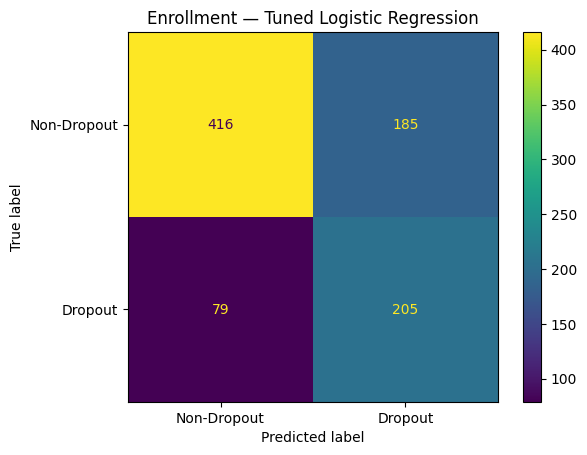

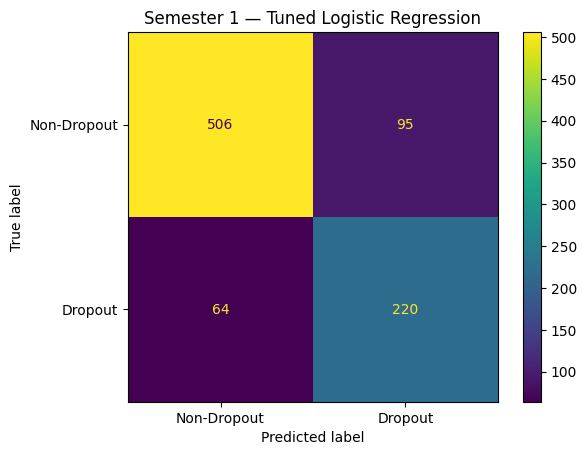

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

for window_name, X_test in [
    ("Enrollment", X_enroll_test),
    ("Semester 1", X_sem1_test)
]:
    model = tuned_logistic_models[window_name]
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Non-Dropout", "Dropout"],
        values_format="d"
    )

    plt.title(f"{window_name} — Tuned Logistic Regression")
    plt.show()

### **Confusion Matrix Assessment**

The Semester 1 model improves both dropout detection and targeting efficiency.

Compared with the Enrollment model, it correctly identifies 15 additional dropouts and reduces false positives by 90 students.

This supports the earlier finding that Semester 1 academic information improves prediction, although the Enrollment model still provides an earlier opportunity for intervention.

In [27]:
top10_results = []

for window_name, X_test in [
    ("Enrollment", X_enroll_test),
    ("Semester 1", X_sem1_test)
]:
    model = tuned_logistic_models[window_name]

    # Predicted dropout probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    ranking = pd.DataFrame({
        "actual_dropout": y_test.to_numpy(),
        "predicted_risk": y_prob
    })

    # Rank students from highest to lowest predicted risk
    ranking = ranking.sort_values(
        "predicted_risk",
        ascending=False
    )

    # Highest-risk 10% of the test population
    top_n = int(np.ceil(len(ranking) * 0.10))
    top_group = ranking.head(top_n)

    total_dropouts = ranking["actual_dropout"].sum()
    captured_dropouts = top_group["actual_dropout"].sum()

    recall_at_10 = captured_dropouts / total_dropouts
    precision_at_10 = captured_dropouts / top_n

    top10_results.append({
        "Prediction Window": window_name,
        "Students in Top 10%": top_n,
        "Actual Dropouts Captured": int(captured_dropouts),
        "Total Actual Dropouts": int(total_dropouts),
        "Recall@Top 10%": recall_at_10,
        "Precision@Top 10%": precision_at_10,
        "Dropouts per 100 Interventions": precision_at_10 * 100
    })

top10_results_df = pd.DataFrame(top10_results)

top10_results_df.round(3)

,Prediction Window,Students in Top 10%,Actual Dropouts Captured,Total Actual Dropouts,Recall@Top 10%,Precision@Top 10%,Dropouts per 100 Interventions
0,Enrollment,89,73,284,0.257,0.820,82.022
1,Semester 1,89,88,284,0.310,0.989,98.876


### **Limited-Capacity Intervention Assessment**

If the institution can support only the highest-risk 10% of students, the Enrollment model captures 73 of 284 actual dropouts, corresponding to a Recall@Top 10% of 25.7%.

The Semester 1 model performs better under the same capacity constraint, capturing 88 of 284 actual dropouts, or 31.0%.

The students ranked in the top 10% are also highly concentrated with actual dropout cases. Precision@Top 10% is 82.0% for Enrollment and 98.9% for Semester 1 in this test sample.

This reinforces the trade-off between timing and targeting quality: the Enrollment model can support earlier intervention, while the Semester 1 model provides a more concentrated high-risk group once academic performance information becomes available.

These values describe performance on the current held-out sample and should be validated on future student cohorts before operational deployment.

In [28]:
import joblib
import json

models_dir = repo_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Save final fitted models
enrollment_model_path = models_dir / "enrollment_logistic_model.joblib"
semester1_model_path = models_dir / "semester1_logistic_model.joblib"

joblib.dump(
    tuned_logistic_models["Enrollment"],
    enrollment_model_path
)

joblib.dump(
    tuned_logistic_models["Semester 1"],
    semester1_model_path
)

# Save model configuration
model_config = {
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "cross_validation_folds": 5,
    "primary_metric": "Dropout Recall",
    "enrollment_model": {
        "algorithm": "Logistic Regression",
        "C": 0.1,
        "class_weight": "balanced"
    },
    "semester1_model": {
        "algorithm": "Logistic Regression",
        "C": 1,
        "class_weight": "balanced"
    }
}

config_path = models_dir / "model_config.json"

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=4)

print("Saved:", enrollment_model_path)
print("Saved:", semester1_model_path)
print("Saved:", config_path)

Saved: /content/student-dropout-capstone/models/enrollment_logistic_model.joblib
Saved: /content/student-dropout-capstone/models/semester1_logistic_model.joblib
Saved: /content/student-dropout-capstone/models/model_config.json


In [29]:
results_dir = repo_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

cv_path = results_dir / "model_selection_cv_results.csv"
test_path = results_dir / "final_test_results.csv"
top10_path = results_dir / "top10_intervention_results.csv"

model_selection_comparison.to_csv(cv_path, index=False)
final_test_results_df.to_csv(test_path, index=False)
top10_results_df.to_csv(top10_path, index=False)

print("Saved:", cv_path)
print("Saved:", test_path)
print("Saved:", top10_path)

Saved: /content/student-dropout-capstone/results/model_selection_cv_results.csv
Saved: /content/student-dropout-capstone/results/final_test_results.csv
Saved: /content/student-dropout-capstone/results/top10_intervention_results.csv


## **Step 4 Summary**

Multiple supervised classification models were implemented and compared using stratified 5-fold cross-validation.

The evaluated approaches included:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Logistic Regression with L1 feature selection
- Logistic Regression with PCA

Hyperparameter tuning was performed using training data only. Tuned Logistic Regression was selected as the primary model for both prediction windows because it achieved the highest dropout recall while maintaining competitive F1, ROC-AUC, and PR-AUC.

On the held-out test set:

- Enrollment model recall: 0.722
- Semester 1 model recall: 0.775

The Semester 1 model also reduced false negatives and false positives compared with the Enrollment model.

For the limited-capacity intervention scenario, the Semester 1 model captured 31.0% of all actual dropouts within the highest-risk 10% of students, compared with 25.7% for the Enrollment model.

The final trained models, model configuration, and evaluation tables were saved as reproducible project artifacts.